In [1]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

In [2]:
from google.colab import files

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/indicBERT_2/Final_Dataset.xlsx - Sheet6.tsv"
df_org = pd.read_csv(file_path, sep='\t')
df_org = df_org.sample(frac=1.0, random_state = 42)
df_org.head()

,Category,Marathi
4871,गळा,लांब प्रवास करताना मानेच्या योग्य स्थितीची काळ...
17948,प्रतिसाद,काही वेळा योग्य उत्तर मिळवण्यासाठी अधिक खोलवर ...
5943,बसणे,सगळी कामं झाल्यावर तिने आरामात पलंगावर बसून टी...
11315,पूर्व दिशा,हवाईअड्डा पूर्व दिशेला आहे.
3222,दिवस,बुधवारी आठवणींना उजाळा देतो.


In [ ]:
df_org = df_org.drop_duplicates()

In [ ]:
df_org.head()

,Category,Marathi
4871,गळा,लांब प्रवास करताना मानेच्या योग्य स्थितीची काळ...
17948,प्रतिसाद,काही वेळा योग्य उत्तर मिळवण्यासाठी अधिक खोलवर ...
5943,बसणे,सगळी कामं झाल्यावर तिने आरामात पलंगावर बसून टी...
11315,पूर्व दिशा,हवाईअड्डा पूर्व दिशेला आहे.
3222,दिवस,बुधवारी आठवणींना उजाळा देतो.


In [ ]:
df_org.shape

(17768, 2)

In [ ]:
labels = df_org['Category'].unique().tolist()
labels = [s.strip() for s in labels]
labels

['गळा',
 'प्रतिसाद',
 'बसणे',
 'पूर्व दिशा',
 'दिवस',
 'दुमडणे',
 'इमोशन',
 'नौका',
 'खिळा',
 'क्रिया',
 'नाव',
 'भावना',
 'भूतकाळ',
 'शिक्षा',
 'बाण',
 'चेंडू',
 'किंमत',
 'जलमार्ग',
 'बांधणे',
 'निर्माण',
 'अडचण',
 'गोंधळ',
 'धरण',
 'एकत्र',
 'हुक',
 'चेष्टा',
 'उत्तर दिशा',
 'वळणधारी',
 'आक्रमण',
 'पठार',
 'आदर',
 'किनारा',
 'थांबणे',
 'देठ',
 'करभर',
 'अंक',
 'लग्नाचा प्रस्ताव',
 'दागिना',
 'ब्लिस्टर',
 'सवय',
 'खाद्य',
 'फूलांची माला',
 'वाहन',
 'तुटणे',
 'जड',
 'बाहू',
 'संख्या',
 'परिणाम',
 'हिस्सा',
 'विशेषता',
 'पाठी',
 'धडा',
 'लाकडी फळक',
 'घड्याळ',
 'कागद',
 'मार्ग',
 'जागा',
 'झाडाचे पान',
 'प्रारंभ',
 'फायदे',
 'गुण']

In [ ]:
for key, value in enumerate(labels):
  print(value)

गळा
प्रतिसाद
बसणे
पूर्व दिशा
दिवस
दुमडणे
इमोशन
नौका
खिळा
क्रिया
नाव
भावना
भूतकाळ
शिक्षा
बाण
चेंडू
किंमत
जलमार्ग
बांधणे
निर्माण
अडचण
गोंधळ
धरण
एकत्र
हुक
चेष्टा
उत्तर दिशा
वळणधारी
आक्रमण
पठार
आदर
किनारा
थांबणे
देठ
करभर
अंक
लग्नाचा प्रस्ताव
दागिना
ब्लिस्टर
सवय
खाद्य
फूलांची माला
वाहन
तुटणे
जड
बाहू
संख्या
परिणाम
हिस्सा
विशेषता
पाठी
धडा
लाकडी फळक
घड्याळ
कागद
मार्ग
जागा
झाडाचे पान
प्रारंभ
फायदे
गुण


In [ ]:
NUM_LABELS = len(labels)
id2label = {id: label for id, label in enumerate(labels)}
label2id = {label: id for id, label in enumerate(labels)}

In [ ]:
label2id

{'गळा': 0,
 'प्रतिसाद': 1,
 'बसणे': 2,
 'पूर्व दिशा': 3,
 'दिवस': 4,
 'दुमडणे': 5,
 'इमोशन': 6,
 'नौका': 7,
 'खिळा': 8,
 'क्रिया': 9,
 'नाव': 10,
 'भावना': 11,
 'भूतकाळ': 12,
 'शिक्षा': 13,
 'बाण': 14,
 'चेंडू': 15,
 'किंमत': 16,
 'जलमार्ग': 17,
 'बांधणे': 18,
 'निर्माण': 19,
 'अडचण': 20,
 'गोंधळ': 21,
 'धरण': 22,
 'एकत्र': 23,
 'हुक': 24,
 'चेष्टा': 25,
 'उत्तर दिशा': 26,
 'वळणधारी': 27,
 'आक्रमण': 28,
 'पठार': 29,
 'आदर': 30,
 'किनारा': 31,
 'थांबणे': 32,
 'देठ': 33,
 'करभर': 34,
 'अंक': 35,
 'लग्नाचा प्रस्ताव': 36,
 'दागिना': 37,
 'ब्लिस्टर': 38,
 'सवय': 39,
 'खाद्य': 40,
 'फूलांची माला': 41,
 'वाहन': 42,
 'तुटणे': 43,
 'जड': 44,
 'बाहू': 45,
 'संख्या': 46,
 'परिणाम': 47,
 'हिस्सा': 48,
 'विशेषता': 49,
 'पाठी': 50,
 'धडा': 51,
 'लाकडी फळक': 52,
 'घड्याळ': 53,
 'कागद': 54,
 'मार्ग': 55,
 'जागा': 56,
 'झाडाचे पान': 57,
 'प्रारंभ': 58,
 'फायदे': 59,
 'गुण': 60}

In [ ]:
id2label

{0: 'गळा',
 1: 'प्रतिसाद',
 2: 'बसणे',
 3: 'पूर्व दिशा',
 4: 'दिवस',
 5: 'दुमडणे',
 6: 'इमोशन',
 7: 'नौका',
 8: 'खिळा',
 9: 'क्रिया',
 10: 'नाव',
 11: 'भावना',
 12: 'भूतकाळ',
 13: 'शिक्षा',
 14: 'बाण',
 15: 'चेंडू',
 16: 'किंमत',
 17: 'जलमार्ग',
 18: 'बांधणे',
 19: 'निर्माण',
 20: 'अडचण',
 21: 'गोंधळ',
 22: 'धरण',
 23: 'एकत्र',
 24: 'हुक',
 25: 'चेष्टा',
 26: 'उत्तर दिशा',
 27: 'वळणधारी',
 28: 'आक्रमण',
 29: 'पठार',
 30: 'आदर',
 31: 'किनारा',
 32: 'थांबणे',
 33: 'देठ',
 34: 'करभर',
 35: 'अंक',
 36: 'लग्नाचा प्रस्ताव',
 37: 'दागिना',
 38: 'ब्लिस्टर',
 39: 'सवय',
 40: 'खाद्य',
 41: 'फूलांची माला',
 42: 'वाहन',
 43: 'तुटणे',
 44: 'जड',
 45: 'बाहू',
 46: 'संख्या',
 47: 'परिणाम',
 48: 'हिस्सा',
 49: 'विशेषता',
 50: 'पाठी',
 51: 'धडा',
 52: 'लाकडी फळक',
 53: 'घड्याळ',
 54: 'कागद',
 55: 'मार्ग',
 56: 'जागा',
 57: 'झाडाचे पान',
 58: 'प्रारंभ',
 59: 'फायदे',
 60: 'गुण'}

In [ ]:
df_org['labels'] = df_org.Category.map(lambda x: label2id[x.strip()])
df_org.head()

,Category,Marathi,labels
4871,गळा,लांब प्रवास करताना मानेच्या योग्य स्थितीची काळ...,0
17948,प्रतिसाद,काही वेळा योग्य उत्तर मिळवण्यासाठी अधिक खोलवर ...,1
5943,बसणे,सगळी कामं झाल्यावर तिने आरामात पलंगावर बसून टी...,2
11315,पूर्व दिशा,हवाईअड्डा पूर्व दिशेला आहे.,3
3222,दिवस,बुधवारी आठवणींना उजाळा देतो.,4


In [ ]:
df_org['cleaned_text'] = df_org['Marathi'].str.replace(r'[^\u0900-\u097F\s]', '', regex=True)  # Keep only Marathi characters
df_org['cleaned_text'] = df_org['cleaned_text'].str.lower().str.strip()

In [ ]:
print(df_org)


               Category                                            Marathi  \
4871                गळा  लांब प्रवास करताना मानेच्या योग्य स्थितीची काळ...   
17948          प्रतिसाद  काही वेळा योग्य उत्तर मिळवण्यासाठी अधिक खोलवर ...   
5943               बसणे  सगळी कामं झाल्यावर तिने आरामात पलंगावर बसून टी...   
11315        पूर्व दिशा                        हवाईअड्डा पूर्व दिशेला आहे.   
3222               दिवस                       बुधवारी आठवणींना उजाळा देतो.   
...                 ...                                                ...   
11284        पूर्व दिशा  पर्यावरणातील बदलाच्या दृष्टीने पूर्व दिशा विचा...   
11964              नौका                      आम्ही तलावात नाव प्रवास केला.   
5390                आदर  निसर्गाच्या संवर्धनाला समाजात योग्य तो मान द्य...   
860              दुमडणे     त्याने मोठ्या चादरीच्या घड्या टेबलावर ठेवल्या.   
15795  लग्नाचा प्रस्ताव   स्थळ स्वीकारण्याआधी आई-वडिलांशी सल्लामसलत करावी.   

       labels                                       cleaned_tex

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
X = vectorizer.fit_transform(df_org['cleaned_text'])
y = df_org['Category']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20]
}

In [ ]:
clf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1_weighted')
clf.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'n_estimators': [100, 200, 300]},
             scoring='f1_weighted')

In [ ]:
print(f"Best Parameters: {clf.best_params_}")

Best Parameters: {'max_depth': None, 'n_estimators': 200}


In [ ]:
y_pred = clf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                  precision    recall  f1-score   support

             अंक       0.57      0.46      0.51        59
            अडचण       0.38      0.38      0.38        55
          आक्रमण       0.92      0.82      0.87        60
             आदर       0.52      0.59      0.55        58
           इमोशन       0.81      0.76      0.79        58
      उत्तर दिशा       0.88      0.96      0.91        45
           एकत्र       0.38      0.38      0.38        53
            करभर       0.74      0.89      0.81        56
            कागद       0.77      0.84      0.80        61
           किंमत       0.53      0.38      0.44        68
          किनारा       0.76      0.77      0.77        62
          क्रिया       0.57      0.83      0.67        52
           खाद्य       0.74      0.92      0.82        62
            खिळा       0.50      0.60      0.55        53
             गळा       0.45      0.35      0.40        65
           गोंधळ       0.80      0.91      0.85 

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2337 (\N{DEVANAGARI LETTER DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib

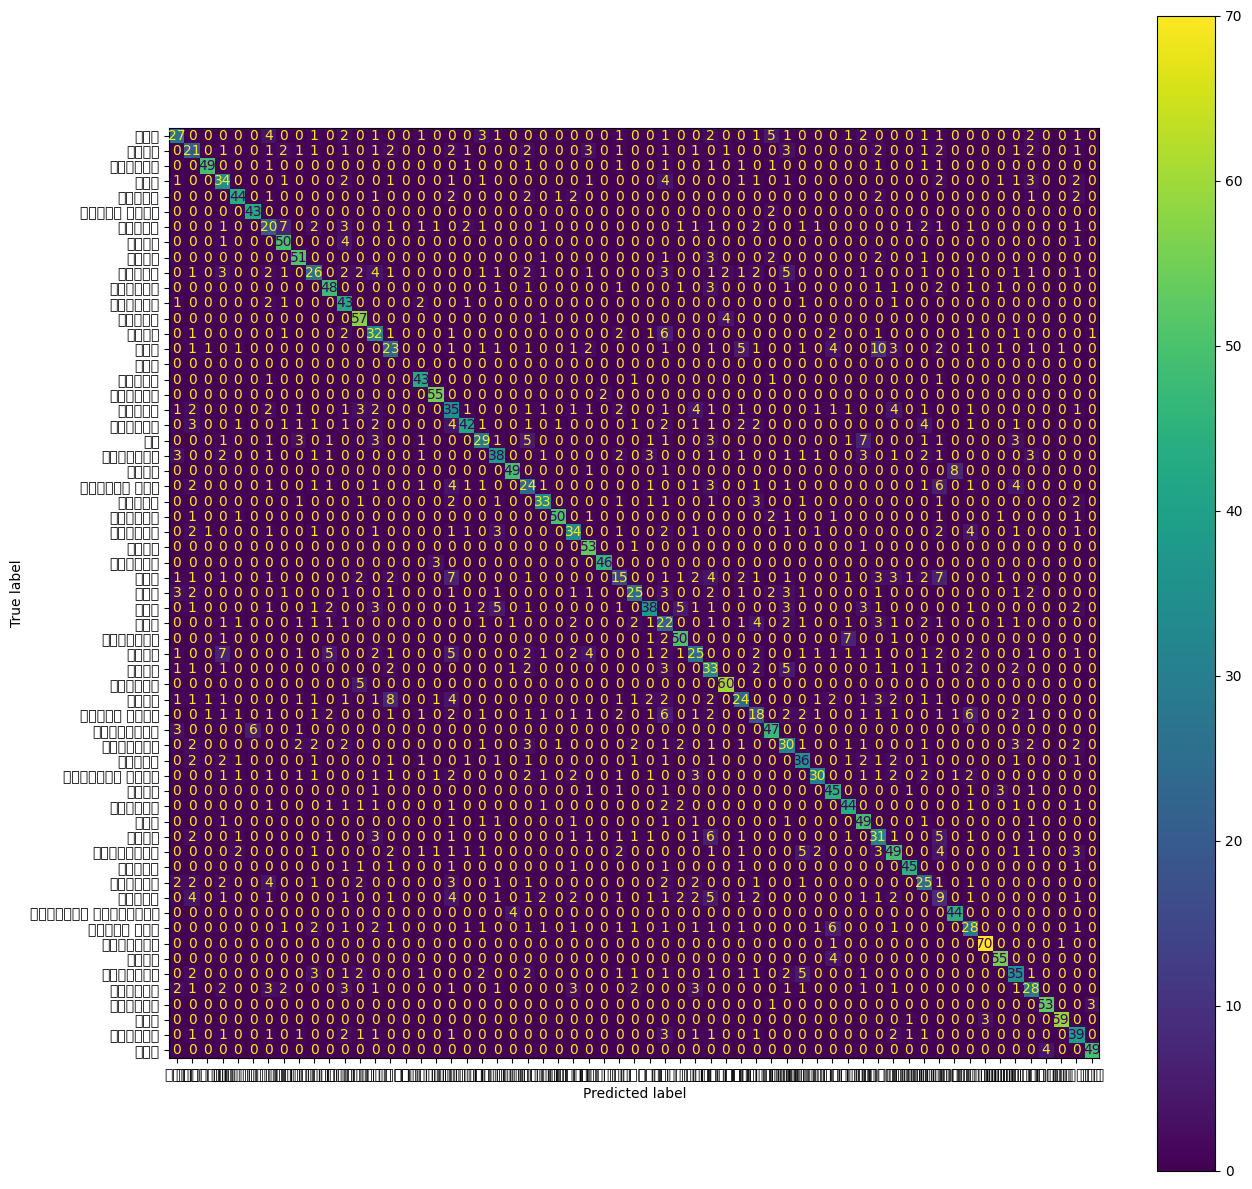

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(ax=ax)  # Pass the axes to the plot method

plt.show()

In [ ]:
joblib.dump(vectorizer, '/content/drive/MyDrive/ngrams/vectorizer (1).pkl')
print("Vectorizer saved successfully.")

Vectorizer saved successfully.


In [ ]:
import joblib

# Load the saved classifier
clf = joblib.load('/content/drive/MyDrive/ngrams/wsd_classifier.pkl')
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
import re

# Sample input Marathi sentence for testing
new_text = "पहाटे पहिल्या बसने निघालो की ट्रॅफिक टळते."

# Preprocess the input
cleaned_text = re.sub(r'[^\u0900-\u097F\s]', '', new_text).lower().strip()

# Transform the input using the same vectorizer
vectorized_input = vectorizer.transform([cleaned_text])


In [ ]:
# Predict the sense for the new input
predicted_sense = clf.predict(vectorized_input)

print("Predicted Sense:", predicted_sense[0])


Predicted Sense: बसणे


In [ ]:
df_org.to_csv('downloaded_dataset.csv', index=False, sep = '\t') # Save to CSV, use '\t' for tab delimiter
files.download('downloaded_dataset.csv') # Download the

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import re
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import os

In [ ]:
dataset_file = '/content/drive/MyDrive/n-gram-RF-RL/Final_Dataset.xlsx - Sheet6.tsv'
if os.path.exists(dataset_file):
    # Use the correct delimiter (sep='\t') when reading the file
    df = pd.read_csv(dataset_file, sep='\t')
else:
    # Initialize an empty DataFrame if no dataset exists
    df = pd.DataFrame(columns=['text', 'sense'])

In [ ]:
try:
    clf = joblib.load('wsd_classifier.pkl')
    vectorizer = joblib.load('vectorizer.pkl')
    print("Model and vectorizer loaded.")
except:
    print("Initializing new model and vectorizer.")
    vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
    clf = RandomForestClassifier(n_estimators=200, random_state=42)


Model and vectorizer loaded.


In [ ]:
def preprocess_text(text):
    return re.sub(r'[^\u0900-\u097F\s]', '', text).lower().strip()

In [ ]:
# **Reinforcement Learning Loop**
while True:
    # Take user input
    new_sentence = input("\nEnter a Marathi sentence (or 'exit' to stop): ")
    if new_sentence.lower() == 'exit':
        break

    # Preprocess and vectorize the input
    cleaned_text = preprocess_text(new_sentence)
    vectorized_input = vectorizer.transform([cleaned_text])

    # Predict the sense
    predicted_sense = clf.predict(vectorized_input)[0]
    print(f"Predicted Sense: {predicted_sense}")

    # Human feedback
    correct_sense = input("Is this correct? (yes/no) or provide the correct sense: ")

    if correct_sense.lower() == 'yes':
        reward = 1
    elif correct_sense.lower() == 'no':
        reward = -1
        correct_sense = input("Please provide the correct sense: ")
    else:
        reward = 1  # User directly provided the correct sense

    print(f"Reward: {reward}")

    # Update the dataset with new data
    df = pd.concat([df, pd.DataFrame({'Marathi': [new_sentence], 'Category': [correct_sense]})], ignore_index=True)

    # Periodically retrain the model if new data is added
    if len(df) % 5 == 0:  # Retrain every 5 new examples
        print("\nRetraining the model...")
        df['cleaned_text'] = df['Marathi'].apply(preprocess_text)

        # Vectorize the entire dataset
        X = vectorizer.fit_transform(df['cleaned_text'])
        y = df['Category']

        # Retrain the model
        clf.fit(X, y)

        # Save the updated model and vectorizer
        joblib.dump(clf, 'wsd_classifier.pkl')
        joblib.dump(vectorizer, 'vectorizer.pkl')

        print("Model retrained and saved.")


Enter a Marathi sentence (or 'exit' to stop): आमच्या मुलाचा विवाह निश्चित झाला आहे, कृपया नवीन स्थळ पाठवू नका.
Predicted Sense: जागा
Is this correct? (yes/no) or provide the correct sense: लग्नाचा प्रस्ताव 
Reward: 1

Retraining the model...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Model retrained and saved.

Enter a Marathi sentence (or 'exit' to stop):  आमच्या मुलाचा विवाह निश्चित झाला आहे, कृपया नवीन स्थळ पाठवू नका.
Predicted Sense: लग्नाचा प्रस्ताव 
Is this correct? (yes/no) or provide the correct sense: yes
Reward: 1

Enter a Marathi sentence (or 'exit' to stop): तो व्यक्ती मुक्का आहे.
Predicted Sense: मार्ग
Is this correct? (yes/no) or provide the correct sense: मूकबधिर
Reward: 1

Enter a Marathi sentence (or 'exit' to stop): मी तुझा मुक्का घेतला.
Predicted Sense: चेंडू
Is this correct? (yes/no) or provide the correct sense: चुंबन
Reward: 1

Enter a Marathi sentence (or 'exit' to stop): मी तुला जोरात मुक्का मारला.
Predicted Sense: तुटणे
Is this correct? (yes/no) or provide the correct sense: नदी पूर्व दिशेने वळते.
Reward: 1

Enter a Marathi sentence (or 'exit' to stop):  मी तुला जोरात मुक्का मारला.
Predicted Sense: तुटणे
Is this correct? (yes/no) or provide the correct sense: घूंसा
Reward: 1

Retraining the model...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Model retrained and saved.

Enter a Marathi sentence (or 'exit' to stop): मी तुला जोरात मुक्का मारला.
Predicted Sense: घूंसा
Is this correct? (yes/no) or provide the correct sense: yes
Reward: 1

Enter a Marathi sentence (or 'exit' to stop): exit


In [ ]:
df.to_csv(dataset_file, index=False)
print("Dataset updated and saved.")

Dataset updated and saved.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
joblib.dump(clf, '/content/drive/MyDrive/n-gram-RF-RL/wsd_classifier.pkl')
joblib.dump(vectorizer, '/content/drive/MyDrive/n-gram-RF-RL/vectorizer.pkl')
df.to_csv('/content/drive/MyDrive/n-gram-RF-RL/wsd_dataset.csv', index=False)